# Limpieza de outliers — preparación para el árbol de finishers

Objetivo del modelo: predecir `finisher_d`/`finisher_h` (o su suma, `total_finishers`) a partir de `distancia`, `tipo_modalidad`, `publico`, `dia_semana`, ubicación, etc.

Este notebook parte de `DF_TODAS.csv` (la unión de las 10 fuentes) y es un fichero **aparte**: la limpieza de outliers depende de para qué se va a usar la tabla, así que no debe mezclarse con `DF_TODAS.csv` (que es la versión "cruda pero bien tipada" que sirve para cualquier análisis).

Dos cosas importantes antes de tocar nada:

1. **Los árboles de decisión son poco sensibles a los outliers** en las variables predictoras — dividen el espacio por umbrales de orden (¿es `distancia > 21`?), no por distancia numérica, así que un valor extremo aislado no distorsiona el árbol como sí haría en una regresión lineal. Por eso aquí NO se recortan/eliminan agresivamente los valores grandes por defecto — se deja como paso opcional, comentado, para si en algún momento se prueban también modelos sensibles a la escala.
2. **Lo que sí hay que arreglar siempre, sea cual sea el modelo:** `distancia == 0` no significa "carrera de 0 km" — es el valor centinela que usamos en las 10 fuentes para "no se pudo extraer la distancia" (dos tercios de las filas en varias fuentes). Si se deja tal cual, el árbol aprendería una relación falsa "distancia baja -> pocos finishers" basada en datos que en realidad son NaN disfrazados.

In [6]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RUTA = Path("../../data/processed/union/DF_TODAS.csv")
df = pd.read_csv(RUTA, encoding="utf-8-sig")
df["fecha"] = pd.to_datetime(df["fecha"])
df["total_finishers"] = df["finisher_d"] + df["finisher_h"]

print("Filas x columnas:", df.shape)
df.head()

Filas x columnas: (42908, 13)


,fuente,nombre_carrera,fecha,dia_semana,distancia,tipo_modalidad,publico,finisher_d,finisher_h,municipio,comarca,provincia,total_finishers
0,buscametas,Areta Trail Lasterketa,2026-07-25,Sábado,0.0,trail running,Absoluta/General,17,147,Areta,NaN,Álava,164
1,buscametas,Epic Gravel Ezcaray,2026-07-25,Sábado,0.0,Ciclismo y btt,Absoluta/General,0,30,Ezcaray,NaN,La Rioja,30
2,buscametas,Epic Gravel Ezcaray,2026-07-25,Sábado,93.0,Ciclismo y btt,Absoluta/General,2,38,Ezcaray,NaN,La Rioja,40
3,buscametas,Epic Gravel Ezcaray,2026-07-25,Sábado,57.0,Ciclismo y btt,Absoluta/General,2,31,Ezcaray,NaN,La Rioja,33
4,buscametas,Epic Gravel Ezcaray,2026-07-25,Sábado,42.0,Ciclismo y btt,Absoluta/General,2,10,Ezcaray,NaN,La Rioja,12


In [7]:
# "distancia == 0" es el centinela de "desconocida" en las 10 fuentes,
# no un valor real — lo pasamos a NaN. Guardamos también un booleano
# "distancia_conocida" como columna propia: puede ser una feature útil
# para el árbol (que la distancia se sepa o no a veces correlaciona con
# el tipo de fuente/categoría) y evita perder esa información al
# convertir a NaN.
#
# Usamos np.nan (no pd.NA): con pd.NA, "distancia" pasa a dtype "object"
# y luego cosas como df.nlargest("distancia") fallan con TypeError. Con
# np.nan la columna se queda en float64, que es lo que necesitamos.
import numpy as np

print("% de filas con distancia == 0, por fuente:")
print((df.groupby("fuente")["distancia"].apply(lambda s: (s == 0).mean() * 100)).round(1))

df["distancia_conocida"] = df["distancia"] != 0
df["distancia"] = df["distancia"].replace(0, np.nan)

print()
print("distancia dtype:", df["distancia"].dtype)
print("Filas con distancia ahora NaN:", df["distancia"].isna().sum(), "de", len(df))

% de filas con distancia == 0, por fuente:
fuente
buscametas          66.6
carreirasgalegas     1.1
ccnorte             66.1
cronofinisher       85.1
cruzandolameta      22.9
cursescat            4.5
iter5               34.2
mychip              13.6
sportmaniacs        65.9
xipgroc             63.7
Name: distancia, dtype: float64

distancia dtype: float64
Filas con distancia ahora NaN: 22587 de 42908


In [8]:
# "total_finishers == 0" (target) — comprobamos que no sean basura antes
# de decidir si son outliers a quitar o datos legítimos a conservar.
# Están repartidas entre casi todas las fuentes (no es un fallo puntual
# de una sola), y cada `Limpieza_<fuente>.ipynb` ya descartó antes los
# eventos sin resultados reales (estat "error"/"sense_resultats"/etc.) —
# así que estas filas en 0 son categorías reales que, dentro de un
# evento con resultados, no tuvieron ningún finisher de ningún género
# (p.ej. una categoría "silla de ruedas" o "SUB8" muy minoritaria). Las
# mantenemos: son el extremo bajo real de la distribución, no ruido.
print("Filas con total_finishers == 0, por fuente:")
print(df.loc[df["total_finishers"] == 0, "fuente"].value_counts())
print()
print(f"Total: {(df['total_finishers'] == 0).sum()} de {len(df)} "
      f"({100 * (df['total_finishers'] == 0).mean():.1f}%)")

Filas con total_finishers == 0, por fuente:
fuente
carreirasgalegas    1858
ccnorte             1412
mychip              1247
cronofinisher       1030
sportmaniacs         295
xipgroc               28
buscametas            26
Name: count, dtype: int64

Total: 5896 de 42908 (13.7%)


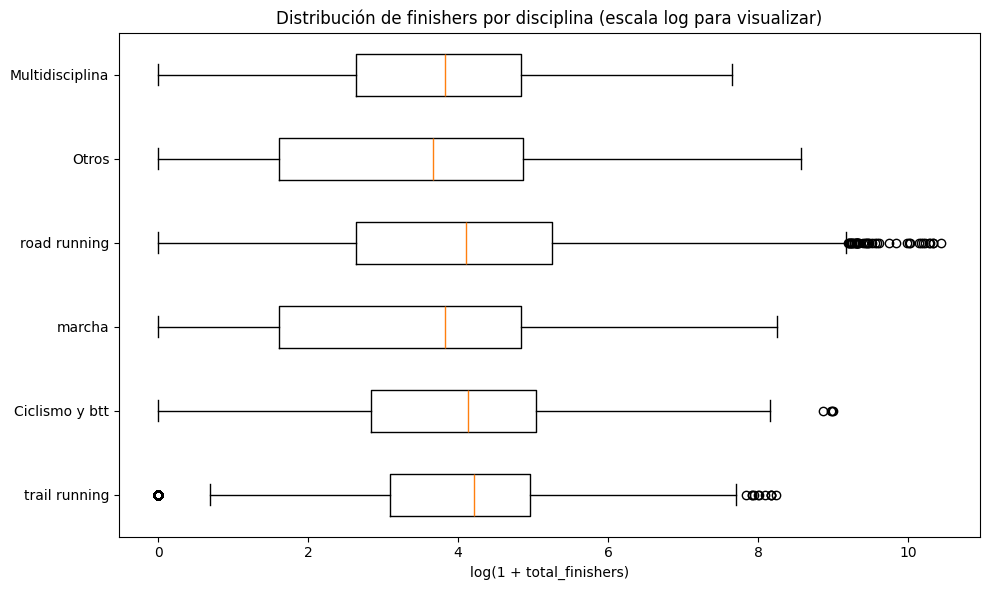

,count,mean,std,min,50%,90%,99%,max
tipo_modalidad,,,,,,,,
Ciclismo y btt,2526.0,154.578781,419.270756,0.0,61.0,322.5,1812.50,8107.0
Multidisciplina,2249.0,110.157403,174.876044,0.0,45.0,300.0,867.84,2096.0
Otros,3580.0,125.084358,297.204123,0.0,38.0,318.2,1204.13,5271.0
marcha,1231.0,110.172218,274.739261,0.0,45.0,244.0,1066.90,3812.0
road running,24618.0,261.571046,984.401135,0.0,60.0,473.0,4099.43,34123.0
trail running,8704.0,104.404527,162.265594,0.0,66.0,237.7,538.97,3789.0


In [9]:
# Distribución de "total_finishers" por tipo_modalidad. La escala es MUY
# distinta entre disciplinas (una maratón de road running puede tener
# miles de finishers; un trail, cientos) — por eso cualquier criterio de
# outlier ("es raro que una fila tenga más de X finishers") debe mirarse
# POR GRUPO, no con un único umbral global. Usamos log1p en el eje solo
# para que el boxplot sea legible (la variable en sí no se transforma).
import numpy as np

fig, ax = plt.subplots(figsize=(10, 6))
tipos = df["tipo_modalidad"].unique()
datos = [np.log1p(df.loc[df["tipo_modalidad"] == t, "total_finishers"]) for t in tipos]
ax.boxplot(datos, tick_labels=tipos, vert=False)
ax.set_xlabel("log(1 + total_finishers)")
ax.set_title("Distribución de finishers por disciplina (escala log para visualizar)")
plt.tight_layout()
plt.show()

df.groupby("tipo_modalidad")["total_finishers"].describe(percentiles=[.5, .9, .99])

In [10]:
# Revisamos a mano las filas más extremas (top 20 por total_finishers y
# por distancia) para descartar errores de scraping/parseo antes de
# decidir si son outliers de verdad o simplemente eventos grandes reales.
pd.set_option("display.max_colwidth", 60)
cols = ["fuente", "nombre_carrera", "distancia", "tipo_modalidad", "total_finishers"]

print("Top 20 por total_finishers:")
print(df.nlargest(20, "total_finishers")[cols].to_string(index=False))
print()
print("Top 20 por distancia:")
print(df.nlargest(20, "distancia")[cols].to_string(index=False))

Top 20 por total_finishers:
      fuente                                                nombre_carrera  distancia tipo_modalidad  total_finishers
sportmaniacs                                          #LaVallecanaEMOCIONA        NaN   road running            34123
sportmaniacs    Nationale-Nederlanden San Silvestre Vallecana Popular 2023     10.000   road running            30839
sportmaniacs                            Carrera de la mujer Barcelona 2019      8.000   road running            30597
sportmaniacs                            Carrera de la Mujer Barcelona 2018      7.800   road running            29417
sportmaniacs    Nationale-Nederlanden San Silvestre Vallecana Popular 2022     10.000   road running            29150
sportmaniacs                         Carrera de la Mujer de Barcelona 2016      7.800   road running            27558
sportmaniacs                            Carrera de la Mujer Barcelona 2023        NaN   road running            27009
sportmaniacs                

### Lo que se ve en esa revisión

Todos los valores extremos revisados son **eventos reales**, no errores de parseo: maratones/10K masivos con miles de finishers, pruebas de ultrafondo (100-300 km) y un par de retos de "todo el verano" tipo "LAB:TRAIL" (934 km / 476 km) que son un reto acumulado de varios meses, no una carrera de un día — legítimos, pero conviene tenerlo en cuenta si luego se interpreta "distancia" como "una carrera = un día".

**Caveat encontrado aquí, corregido más tarde en origen:** unas pocas carreras de ciclismo de fondo real (`Mallorca 312`, `MOZARABE BIKE RACE`, `SB Hotels La Garba`) estaban clasificadas como `tipo_modalidad == "road running"` en vez de `"Ciclismo y btt"` — un fallo de las palabras clave en `Limpieza_sportmaniacs.ipynb`/`Limpieza_cruzandolameta.ipynb` (el texto de esa fila en concreto no contenía "btt"/"ciclis"). Como era un problema de **clasificación**, no de outliers, no se tocó aquí en su momento — se corrigió directamente en esos dos notebooks (excepción por nombre de carrera, ver su celda de clasificación de `tipo_modalidad`), que ya regeneraron sus `DF_*_LIMPIO.csv` con el fix aplicado. `DF_TODAS.csv` (generado por `EDA_finishers_carreras.ipynb`) ya incorpora la corrección; el `DF_TODAS_SIN_OUTLIERS.csv` que genera este notebook seguirá arrastrando el error mientras no se vuelva a ejecutar sobre un `DF_TODAS.csv` regenerado — pendiente si se retoma este notebook.

### Winsorización opcional (desactivada por defecto)

Como se explica arriba, para un árbol/random forest esto normalmente **no hace falta** — los valores altos son reales, no ruido, y el árbol no se ve arrastrado por ellos como una regresión lineal. Se deja aquí como interruptor por si en algún momento se prueba un modelo sensible a la escala (regresión lineal, KNN, SVM...): recorta `total_finishers` al percentil 99 **dentro de cada `tipo_modalidad`** (nunca con un umbral global, por la diferencia de escala entre disciplinas que se ve en el boxplot).

In [11]:
APLICAR_WINSORIZACION = False  # cámbialo a True solo si vas a probar un modelo sensible a la escala

if APLICAR_WINSORIZACION:
    for col in ["finisher_d", "finisher_h", "total_finishers"]:
        limite = df.groupby("tipo_modalidad")[col].transform(lambda s: s.quantile(0.99))
        col_capada = f"{col}_capado"
        df[col_capada] = df[col].clip(upper=limite)
        print(f"{col}: {(df[col] > limite).sum()} filas recortadas -> '{col_capada}'")
else:
    print("Winsorización desactivada — se conservan finisher_d/finisher_h/total_finishers tal cual "
          "(recomendado para árboles/random forest).")

Winsorización desactivada — se conservan finisher_d/finisher_h/total_finishers tal cual (recomendado para árboles/random forest).


In [12]:
# Vista final: qué ha cambiado respecto a DF_TODAS.csv.
print("Columnas:", list(df.columns))
print("Filas x columnas:", df.shape)
print()
print("distancia — nulos (antes eran 0):", df["distancia"].isna().sum())
print("distancia_conocida value_counts:")
print(df["distancia_conocida"].value_counts())
print()
df.sample(10)

Columnas: ['fuente', 'nombre_carrera', 'fecha', 'dia_semana', 'distancia', 'tipo_modalidad', 'publico', 'finisher_d', 'finisher_h', 'municipio', 'comarca', 'provincia', 'total_finishers', 'distancia_conocida']
Filas x columnas: (42908, 14)

distancia — nulos (antes eran 0): 22587
distancia_conocida value_counts:
distancia_conocida
False    22587
True     20321
Name: count, dtype: int64



,fuente,nombre_carrera,fecha,dia_semana,distancia,tipo_modalidad,publico,finisher_d,finisher_h,municipio,comarca,provincia,total_finishers,distancia_conocida
14333,mychip,Costa Blanca Trails 2023,2023-11-17,Viernes,21.0,trail running,Absoluta/General,91,300,Finestrat,La Marina Baja,Comunidad Valenciana,391,True
42424,cruzandolameta,CxM DEL ZENETE 5.0,2018-08-26,Domingo,12.0,trail running,Absoluta/General,24,110,Lanteira,Comarca de Guadix,Granada,134,True
41393,cruzandolameta,IX ALPUJARRA MAGNA GRAN FONDO,2025-09-20,Sábado,133.0,Ciclismo y btt,Absoluta/General,19,511,Lanjarón,Comarca de la Alpujarra Granadina,Granada,530,True
37242,sportmaniacs,38a VOLTA A PEU A QUARTELL,2018-07-14,Sábado,NaN,road running,Absoluta/General,30,173,Quartell,NaN,Valencia,203,False
17156,mychip,XI Carrera Popular per a Persones amb Diversitat Funcion...,2016-04-28,Jueves,NaN,road running,Absoluta/General,0,0,Játiva,La Costera,Comunidad Valenciana,0,False
17163,mychip,Carrera de la Dona de Salem,2016-04-24,Domingo,NaN,road running,Absoluta/General,0,0,Salem,La Vall d'Albaida,Comunidad Valenciana,0,False
32952,sportmaniacs,Trail Senyor del Castell 2026,2026-06-07,Domingo,NaN,marcha,Absoluta/General,55,38,Palafolls,Maresme,Barcelona,93,False
6519,ccnorte,CORRE CON NOS XII+I AS GANDARAS 5300M,2012-12-15,Sábado,5.3,road running,Absoluta/General,0,0,NaN,NaN,NaN,0,True
30116,sportmaniacs,XIX HERRI KROSA ETXEBARRI,2025-03-23,Domingo,NaN,road running,Absoluta/General,133,369,Etxebarri,NaN,Bizkaia,502,False
24556,sportmaniacs,XLII CROSS INTERNACIONAL DE VENTA DE BAÑOS,2022-12-18,Domingo,NaN,trail running,Mayores/Veteranos,0,28,Venta de Baños,NaN,Palencia,28,False


In [13]:
# Guardamos la tabla lista para modelar (sin sobreescribir DF_TODAS_LIMPIO.csv).
SALIDA = Path("../../data/processed/union/DF_TODAS_SIN_OUTLIERS.csv")
df.to_csv(SALIDA, index=False, encoding="utf-8-sig")
print(f"Guardado en {SALIDA}")

Guardado en C:\Users\Clàudia Rafart\OneDrive - Prenomics\Escritorio\Altres\analisis_data\DF_TODAS_SIN_OUTLIERS.csv
